In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [3]:
filename = "S_NWC_CBH_noaa21_00000_20250305T0115421Z_20250305T0117068Z.nc"
filename = "S_NWC_CBH_noaa20_00000_20250305T0017229Z_20250305T0018474Z.nc"
filename = "S_NWC_CBH_noaa18_00000_20250324T1817553Z_20250324T1831046Z.nc"
filename = "S_NWC_CBH_npp_00000_20250320T0519369Z_20250320T0521011Z.nc"
filename = "S_NWC_CBH_metopc_00000_20250324T2033499Z_20250324T2048367Z.nc"
filename = "S_NWC_CBH_noaa18_00000_20250302T0801503Z_20250302T0813307Z.nc"
filename = "S_NWC_CBH_metopb_00000_20250331T0724539Z_20250331T0739116Z.nc"
                                                                                                                                                                                                          
cth_filename = filename.replace("CBH", "CTTH")
old_file =  f"/nobackup/smhid20/users/sm_indka/data/pps/export/viirs_algo/{filename}"
new_file = f"/nobackup/smhid20/users/sm_indka/data/pps/export/{filename}"
cth_file = f"/nobackup/smhid20/users/sm_indka/data/pps/export/{cth_filename}"

In [4]:
ds_old = xr.open_dataset(old_file)
ds_new = xr.open_dataset(new_file)
cth = xr.open_dataset(cth_file)

(array([8.00000e+00, 1.15000e+02, 1.84200e+03, 6.95060e+04, 2.82758e+05,
        5.83064e+05, 7.33270e+05, 6.50333e+05, 6.68603e+05, 5.73290e+05,
        4.54416e+05, 3.30737e+05, 2.43153e+05, 1.91625e+05, 1.64049e+05,
        1.40828e+05, 1.24870e+05, 1.10978e+05, 9.83090e+04, 9.08610e+04,
        8.39820e+04, 7.73260e+04, 7.33470e+04, 6.81620e+04, 6.50110e+04,
        6.10780e+04, 5.78740e+04, 5.53550e+04, 5.23100e+04, 5.07080e+04,
        4.84020e+04, 4.56780e+04, 4.48390e+04, 4.36590e+04, 4.19770e+04,
        4.10840e+04, 3.97630e+04, 3.93300e+04, 3.94090e+04, 3.75160e+04,
        3.68420e+04, 3.58340e+04, 3.51420e+04, 3.48700e+04, 3.40060e+04,
        3.37120e+04, 3.27710e+04, 3.15620e+04, 3.10320e+04, 2.95150e+04,
        2.90560e+04, 2.81440e+04, 2.62810e+04, 2.49870e+04, 2.40140e+04,
        2.29900e+04, 2.23690e+04, 2.19410e+04, 2.16650e+04, 2.13040e+04,
        2.10770e+04, 2.16030e+04, 2.17840e+04, 2.16980e+04, 2.23340e+04,
        2.24130e+04, 2.34720e+04, 2.47330e+04, 2.60

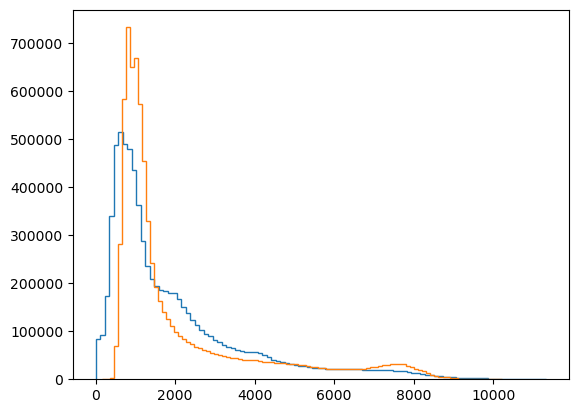

In [5]:
plt.hist(ds_old.cbh_alti[0].data.ravel(), 100, label="old", histtype="step")
plt.hist(ds_new.cbh_alti[0].data.ravel(), 100, label="new", histtype="step")

# plt.hist(ds_old.cbh_pres[0].data.ravel(), 100, label="old", histtype="step")
# plt.hist(ds_new.cbh_pres[0].data.ravel(), 100, label="new", histtype="step")

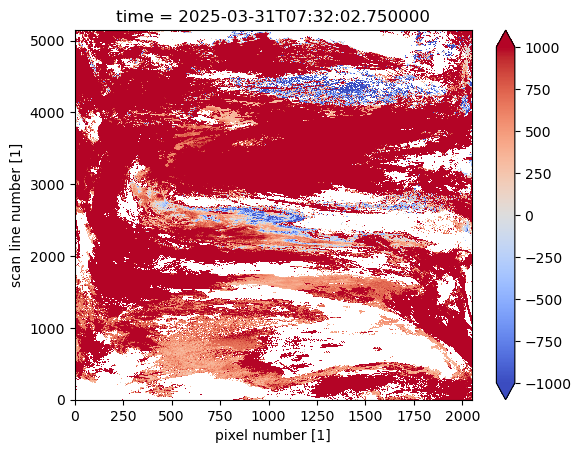

In [6]:
(cth.ctth_alti[0] - ds_old.cbh_alti[0]).plot.pcolormesh(vmin = -1000, vmax = 1000, cmap="coolwarm")

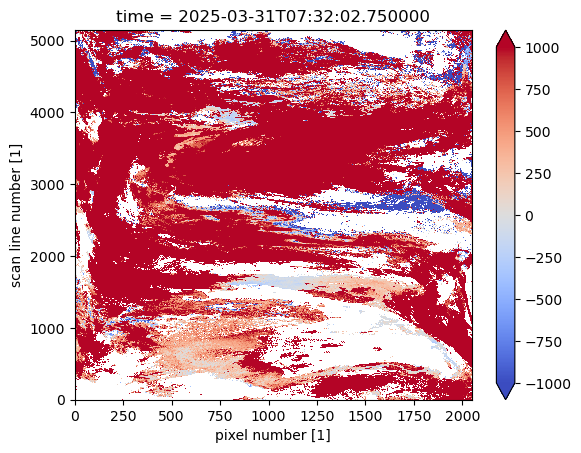

In [7]:
(cth.ctth_alti[0] - ds_new.cbh_alti[0]).plot.pcolormesh(vmin = -1000, vmax = 1000, cmap="coolwarm")

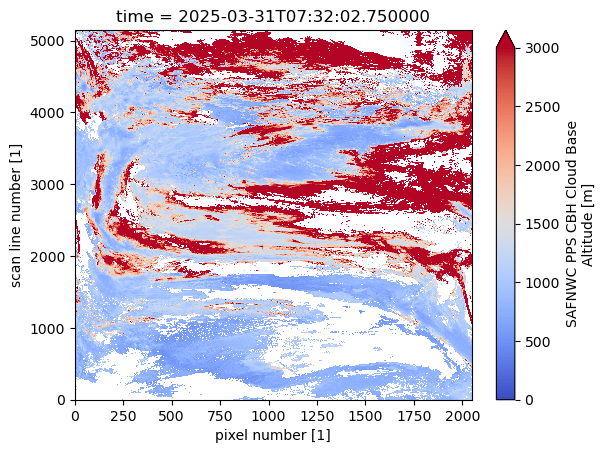

In [8]:
(ds_new.cbh_alti[0]).plot.pcolormesh(vmin = 0, vmax = 3000, cmap="coolwarm")

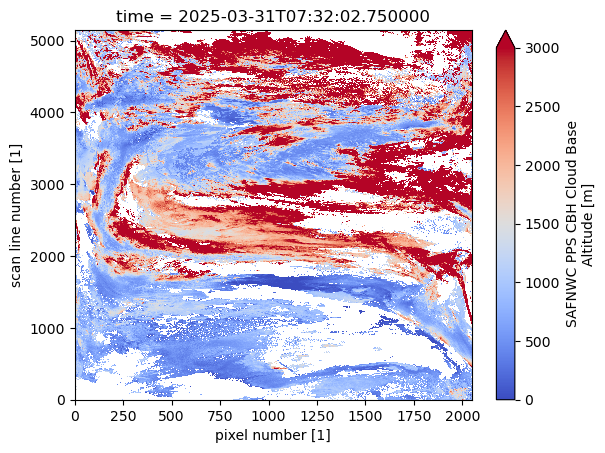

In [9]:
(ds_old.cbh_alti[0]).plot.pcolormesh(vmin = 0, vmax = 3000, cmap="coolwarm")

In [10]:
mask = ds_new.cbh_alti[0].data > 0
np.sum((cth.ctth_alti[0].data[mask] - ds_new.cbh_alti[0].data[mask]).ravel() < 0)/ds_new.cbh_alti[0].data[mask].size

0.08761015166418247

In [11]:
ds_new

<xarray.Dataset> Size: 590MB
Dimensions:          (time: 1, nv: 2, ny: 5147, nx: 2048)
Coordinates:
  * time             (time) datetime64[ns] 8B 2025-03-31T07:32:02.750000
    lat              (ny, nx) float32 42MB ...
    lon              (ny, nx) float32 42MB ...
  * nx               (nx) uint16 4kB 0 1 2 3 4 5 ... 2043 2044 2045 2046 2047
  * ny               (ny) uint16 10kB 0 1 2 3 4 5 ... 5142 5143 5144 5145 5146
Dimensions without coordinates: nv
Data variables: (12/13)
    time_bnds        (time, nv) datetime64[ns] 16B ...
    cbh_tempe        (time, ny, nx) float32 42MB ...
    cbh_pres         (time, ny, nx) float32 42MB ...
    cbh_alti         (time, ny, nx) float32 42MB ...
    cbh_hfeet        (time, ny, nx) float32 42MB ...
    cbh_tempe_err    (time, ny, nx) float32 42MB ...
    ...               ...
    cbh_alti_err     (time, ny, nx) float32 42MB ...
    cbh_hfeet_err    (time, ny, nx) float32 42MB ...
    surface_alti     (time, ny, nx) float32 42MB ...
    cbh_conditions   (time, ny, nx) float32 42MB ...
    cbh_quality      (time, ny, nx) float32 42MB ...
    cbh_status_flag  (time, ny, nx) float32 42MB ...
Attributes: (12/28)
    platform:                   Metop-B
    orbit_number:               0
    Conventions:                CF-1.9
    institution:                SMHI
    comment:                    
    references:                 http://www.nwcsaf.org
    ...                         ...
    product_algorithm_version:  vNGI2-incr
    id:                         /nobackup/smhid20/users/sm_indka/data/pps/exp...
    time_coverage_start:        20250331T0724539Z
    time_coverage_end:          20250331T0739116Z
    input_cloudmask:            /nobackup/smhid20/users/sm_indka/data/pps/exp...
    network_used:               nn_modis_avhrr_day_t06_t11_t12

In [12]:
from atrain_match.matchobject_io import read_files
import glob


In [13]:
VAR_NAMES = [
    "validation_pressure_base",  # cloudsat
    "calipso_layer_base_altitude",
    "validation_height_base",
    "cloudsat_cloud_base_temperature",
    #'cloud_base_height', #mora
    # "validation_height",
    #"r06micron_sza_correction_done",
    #"r13micron",
    #"bt37micron",
    "bt11micron",
    "bt12micron",
    "warmest_t11",
    "coldest_t11",
    "warmest_t12",
    "coldest_t12",
    #"text_r06",
    #"text_t37",
    "text_t11",
    "text_t11t12",
    "ciwv",
    "surftemp",
    "psur",
    "nwp_h2m",
    "t250",
    "t500",
    "t700",
    "t850",
    "t950",
    #"nwp_q250",
    #"nwp_q500",
    #"nwp_q700",
    #"nwp_q850",
    #"nwp_q950",
    "ctth_pressure",
    "ctth_height"
]


In [14]:
files = glob.glob("/nobackup/smhid20/users/sm_indka/updated_cloudsat_modis_collocations/validation/1km_eos2_20100801_0000_99999_cloudsat_modis_match.h5")
caObj = read_files(
        files, truth="cloudsat", read_all=False, read_var=VAR_NAMES
    )

files_old = glob.glob("/nobackup/smhid20/proj/safnwc/work/20250204_modis_cloudbase/global_modis_20250213/Reshaped_Files/eos2/1km/merged_cloudsat/training/1km_eos2_20100801_0000_99999_cloudsat_modis_match.h5")
caObj_old = read_files(
        files_old, truth="cloudsat", read_all=False, read_var=VAR_NAMES
    )

In [15]:
ctth_pressure = getattr(caObj.imager, "ctth_pressure")
ctth_pressure_old = getattr(caObj_old.imager, "ctth_pressure")

In [16]:
viirsfile = "/nobackup/smhid20/users/sm_indka/collocated_data/VGAC_PPS/with_cbp_new/split_data/training_data_vgac_cloudsat_caliop_cbp.nc"
ds = xr.open_dataset(viirsfile)


Text(0, 0.5, 'Frequency')

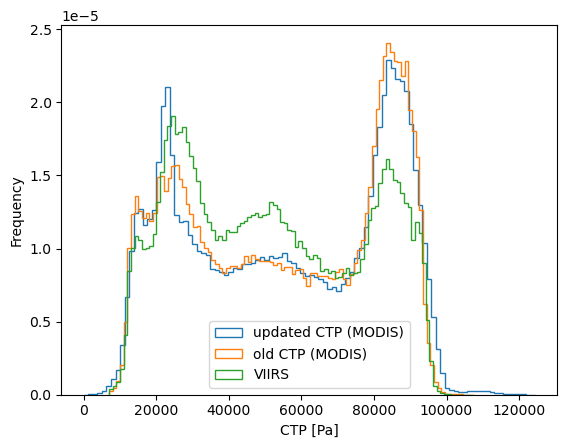

In [17]:
plt.hist(ctth_pressure[ctth_pressure > 10], bins=100, histtype="step", density=True, label="updated CTP (MODIS)")
plt.hist(ctth_pressure_old[ctth_pressure_old > 10], bins=100, histtype="step", density=True, label="old CTP (MODIS)")
plt.hist(ds.ctp.data, bins=100, histtype="step", density=True, label="VIIRS")
plt.legend()
plt.xlabel("CTP [Pa]")
plt.ylabel("Frequency")

In [18]:
ctth_h = getattr(caObj.imager, "ctth_height")
ctth_h_old = getattr(caObj_old.imager, "ctth_height")

(array([1.05968890e-05, 1.12184942e-05, 1.32017109e-05, 2.15193808e-05,
        3.96051327e-05, 7.05965930e-05, 1.22041825e-04, 1.57177320e-04,
        1.54720500e-04, 1.62268563e-04, 1.59190137e-04, 1.75440674e-04,
        1.91217606e-04, 1.96249648e-04, 1.95213640e-04, 1.83787944e-04,
        1.64843785e-04, 1.58272529e-04, 1.54602099e-04, 1.45810825e-04,
        1.34681131e-04, 1.19022600e-04, 1.02979265e-04, 9.83024257e-05,
        9.40103897e-05, 8.94815516e-05, 8.36799029e-05, 8.58703213e-05,
        8.14894845e-05, 8.08974795e-05, 8.22590910e-05, 7.75822517e-05,
        8.11342815e-05, 7.70790475e-05, 7.69014460e-05, 7.87366614e-05,
        8.27918955e-05, 8.15486850e-05, 8.22294907e-05, 7.95062679e-05,
        8.14598843e-05, 8.35911022e-05, 8.39759054e-05, 8.64623263e-05,
        8.86527447e-05, 8.96887534e-05, 8.93631507e-05, 8.77055367e-05,
        8.77647372e-05, 8.88599464e-05, 8.74095342e-05, 8.29990972e-05,
        8.24070922e-05, 8.13414833e-05, 7.70494472e-05, 7.568783

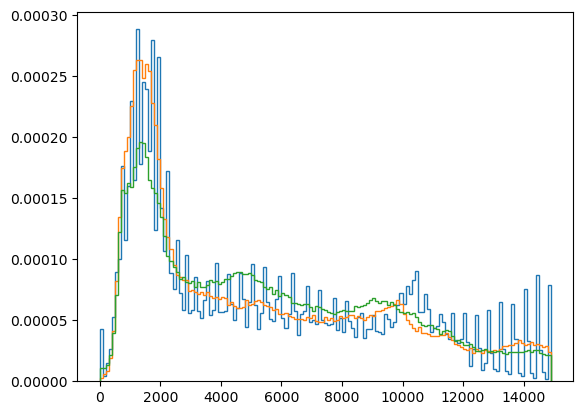

In [19]:
bins = np.arange(0, 15000, 100)
plt.hist(ctth_h[ctth_pressure > 10], bins, histtype="step", density=True)
plt.hist(ctth_h_old[ctth_h_old > 10], bins, histtype="step", density=True)
plt.hist(ds.cth.data[ds.cth.data > 0], bins, histtype="step", density=True)

In [20]:
def get_base_height(caObj):
    data_cloudsat = getattr(caObj.cloudsat, "validation_height_base")
    data_cloudsat[data_cloudsat < 9] = 9999.0
    data_calipso = getattr(caObj.cloudsat, "calipso_layer_base_altitude")
    is_nodata_calipso = data_calipso < -9998
    data_calipso[is_nodata_calipso] = 99.0
    if len(data_calipso.shape) > 1:
        validation_height_base_calipso = 1000 * np.min(data_calipso, axis=1)
    else:
        validation_height_base_calipso = 1000 * data_calipso
    the_data = np.where(
        validation_height_base_calipso < data_cloudsat,
        validation_height_base_calipso,
        data_cloudsat,
    )
    the_data[the_data >= 9000] = -999
    return the_data

cb_new = get_base_height(caObj)
cb_old = get_base_height(caObj_old)


Text(0.5, 0, 'CBH [m]')

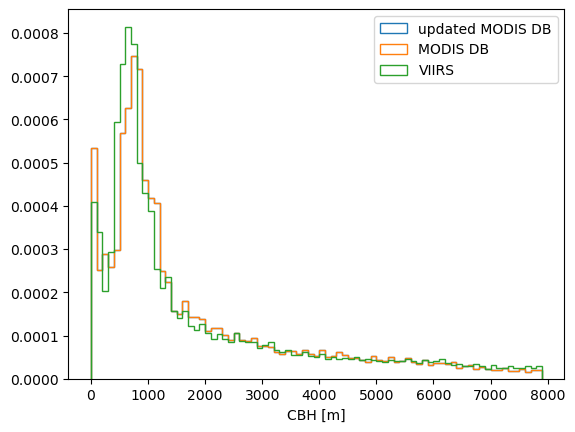

In [21]:
bins=np.arange(0, 8000, 100)
plt.hist(cb_new[cb_new > 0], bins, histtype="step", density=True, label="updated MODIS DB")
plt.hist(cb_old[cb_old > 0], bins, histtype="step", density=True, label="MODIS DB")
plt.hist(ds.cloud_base.data[ds.cloud_base.data > 0], bins, histtype="step", density=True, label="VIIRS")
plt.legend()
plt.xlabel("CBH [m]")


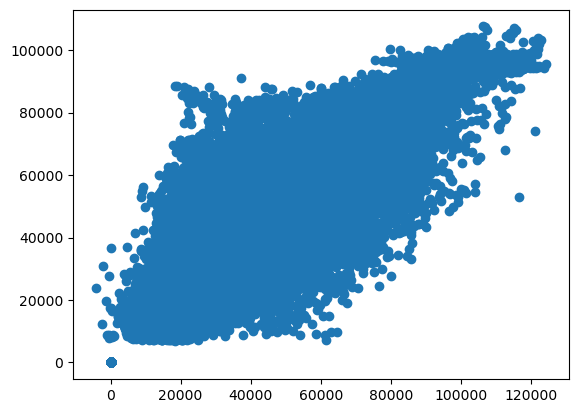

In [22]:
plt.scatter(ctth_pressure, ctth_pressure_old)